In [1]:
import numpy as np
import pandas as pd
import math
from scipy import stats
from sklearn.preprocessing import MinMaxScaler


import matplotlib.pyplot as plt

from SALib.sample import saltelli
from SALib.analyze import sobol

/Users/ajivani/opt/anaconda3/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [36]:
plt.rcParams['figure.dpi'] = 200
plt.style.use('seaborn-v0_8-notebook')
plt.rc("font", 
       family="serif")
plt.rc("axes.spines", top=True, right=True)
# set explicit fontsizes for ticks, lables, legend and title
plt.rc('xtick', labelsize=16)
plt.rc('ytick', labelsize=16)
plt.rc('axes', labelsize=18)
plt.rc('legend', fontsize=12)
plt.rc('figure', titlesize=18)
# set gridlines and grid alpha and grid linestyle
plt.rc('axes', grid=True)
plt.rc('grid', linestyle='--')
plt.rc('grid', alpha=0.8)

In [2]:
def sample_borehole_data(n_samples=1000):
    # Define the distributions for each variable
    r_w = np.random.normal(loc=0.10, scale=0.0161812, size=n_samples)
    r = np.random.lognormal(mean=7.71, sigma=1.0056, size=n_samples)
    T_u = np.random.uniform(63070, 115600, size=n_samples)
    H_u = np.random.uniform(990, 1110, size=n_samples)
    T_l = np.random.uniform(63.1, 116, size=n_samples)
    H_l = np.random.uniform(700, 820, size=n_samples)
    L = np.random.uniform(1120, 1680, size=n_samples)
    K_w = np.random.uniform(9855, 12045, size=n_samples)

    # Combine the samples into a DataFrame
    data = pd.DataFrame({
        'r_w': r_w,
        'r': r,
        'T_u': T_u,
        'H_u': H_u,
        'T_l': T_l,
        'H_l': H_l,
        'L': L,
        'K_w': K_w
    })
    
    return data

# Generate 1000 samples from the joint distribution
data = sample_borehole_data(1000)
data.head()

,r_w,r,T_u,H_u,T_l,H_l,L,K_w
0,0.084443,901.912546,101674.755942,990.285186,91.296298,732.767218,1380.662970,11832.838317
1,0.077934,1230.828659,114899.778276,1028.706805,78.902611,744.594726,1465.382203,11653.271138
2,0.100738,537.381233,104314.245173,1072.580254,70.612946,732.255866,1196.754933,10881.111023
3,0.084688,3283.127387,73741.971656,1086.456048,89.114997,797.611994,1497.114066,11104.461444
4,0.103289,1090.986809,95880.459567,1032.640603,86.631170,772.410596,1603.418588,10546.586006


In [3]:
class Borehole:
    def __init__(self, seed=42):
        self.rw_dist = stats.norm(loc=0.1, scale=0.0161812)
        self.r_dist = stats.lognorm(s=1.0056, scale=np.exp(7.71))
        self.Tu_dist = stats.uniform(63070, 115600)
        self.Hu_dist = stats.uniform(990, 1110)
        self.Tl_dist = stats.uniform(63.1, 116)
        self.Hl_dist = stats.uniform(700, 820)
        self.L_dist = stats.uniform(1120, 1680)
        self.Kw_dist = stats.uniform(9855, 12045)
        self.random_seed = seed

    def sample(self, n_samples=1000):
        """
        Borehole function: response is water flow through borehole in m^3 per year.

        Parameters:
        rw: radius of borehole in m
        r:  radius of influence in m
        Tu: transmissivity of upper aquifer in m^2/year
        Hu: potentiometric head of upper aquifer in m
        Tl: transmissivity of lower aquifer in m^2/year
        Hl: potentiometric head of lower aquifer in m
        Lth:  length of borehole in m
        Kw: hydraulic conductivity of borehole in m/year

        Use distribution objects defined in __init__ to sample n_samples from each parameter distribution. Then compute the water flow rate and return as a numpy array.
        """
        np.random.seed(self.random_seed)
        rw_samples = self.rw_dist.rvs(n_samples)
        r_samples = self.r_dist.rvs(n_samples)
        Tu_samples = self.Tu_dist.rvs(n_samples)
        Hu_samples = self.Hu_dist.rvs(n_samples)
        Tl_samples = self.Tl_dist.rvs(n_samples)
        Hl_samples = self.Hl_dist.rvs(n_samples)
        L_samples = self.L_dist.rvs(n_samples)
        Kw_samples = self.Kw_dist.rvs(n_samples)

        #         input_data = pd.DataFrame({
        #         'r_w': rw_samples,
        #         'r': r_samples,
        #         'T_u': Tu_samples,
        #         'H_u': Hu_samples,
        #         'T_l': Tl_samples,
        #         'H_l': Hl_samples,
        #         'L': L_samples,
        #         'K_w': Kw_samples
        #         })

        
        input_data = np.core.records.fromarrays(
        [rw_samples, 
         r_samples, 
         Tu_samples, 
         Hu_samples, 
         Tl_samples,
         Hl_samples, 
         L_samples, 
         Kw_samples],
        names='r_w, r, T_u, H_u, T_l, H_l, L, K_w'
        )
        
        return input_data
    
    def scale_data(self, X):
        scaler = MinMaxScaler()
        data_array = np.array([X[name] for name in X.dtype.names]).T
        scaled_data = scaler.fit_transform(data_array)
        scaled_data = np.core.records.fromarrays(
        scaled_data_array.T, names=X.dtype.names
        )
        return scaled_data
    
    def evaluate1(self, X):
        """
        In the style of test functions from SALib, take in a
        numpy array with variables in specific order
        """
        n_samples = X.shape[0]
        Q = np.zeros(n_samples)
        for i in range(n_samples):
            numerator = 2 * math.pi * X['T_u'][i] * (X['H_u'][i] - X['H_l'][i])

            denom1 = np.log(X['r'][i] / X['r_w'][i])
            denom2 = 2 * X['L'][i] * X['T_u'][i] / (X['K_w'][i] * X['r'][i]**2)
            denom3 = X['T_u'][i] / X['T_l'][i]

            Q[i] = numerator / (denom1 * (1 + (denom2 / denom1) + denom3))

        return Q
    
    
    def evaluate2(self, X):
        """
        Pass in a regular numpy array instead of recarray in the following
        order of variables: ['r_w', 'r', 'T_u', 'H_u', 'T_l', 'H_l', 'L', 'K_w']
        """
        
        n_samples = X.shape[0]
        Q = np.zeros(n_samples)
        for i in range(n_samples):
            numerator = 2 * math.pi * X[i, 2] * (X[i, 3] - X[i, 5])

            denom1 = np.log(X[i, 1] / X[i, 0])
            denom2 = 2 * X[i, 6] * X[i, 2] / (X[i, 7] * X[i, 1]**2)
            denom3 = X[i, 2] / X[i, 4]

            Q[i] = numerator / (denom1 * (1 + (denom2 / denom1) + denom3))

        return Q

In [4]:
bh = Borehole(seed=47)
bh_inputs = bh.sample(10000)

In [5]:
bh_inputs['r_w'].shape

(10000,)

In [6]:
bh_inputs.shape

(10000,)

In [7]:
bh_output = bh.evaluate1(bh_inputs)

In [8]:
bh_output.shape

(10000,)

In [9]:
def plot_2d_contours(input_data, output_data,
                    xvar='r_w', yvar='r'):
    n_samples = output_data.shape[0]

    x = input_data[xvar]
    y = input_data[yvar]

    plt.figure(figsize=(8, 6))
    plt.tricontourf(x, y, output_data, 
                    levels=20, 
                    cmap='coolwarm')
    plt.colorbar(label='Borehole Flow Rate')
    plt.xlabel(r"${}$".format(xvar))
    plt.ylabel(r"${}$".format(yvar))
    plt.title('Borehole Function Contours')
    plt.show()

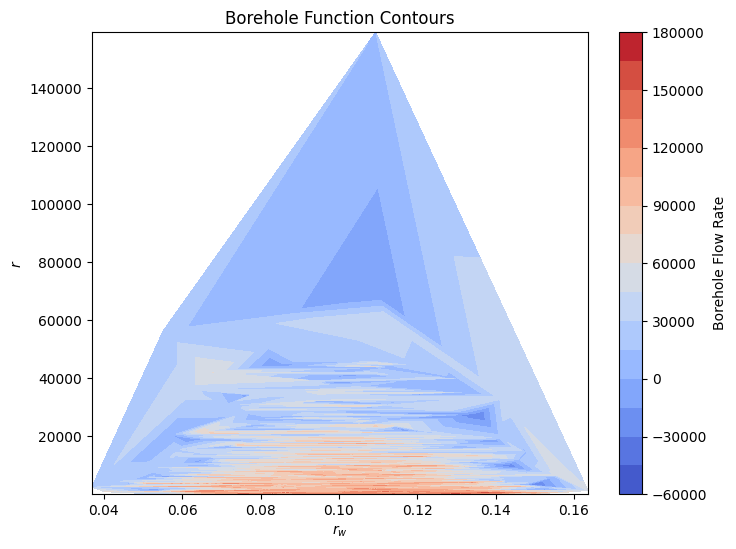

In [10]:
plot_2d_contours(bh_inputs, bh_output)

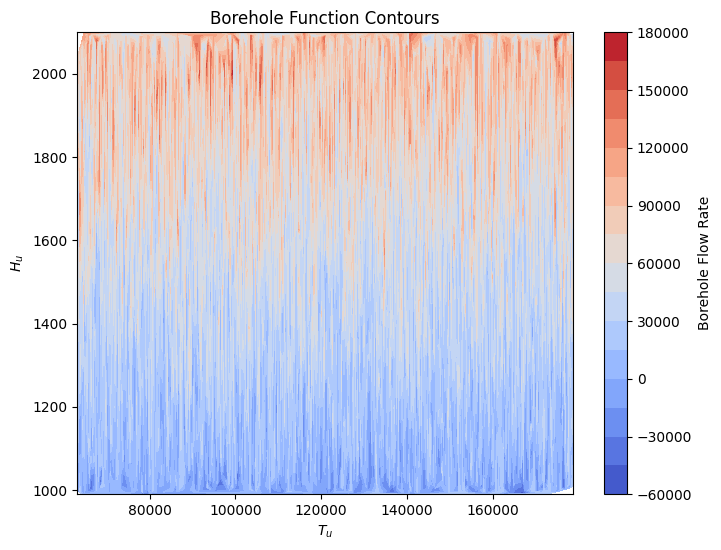

In [11]:
plot_2d_contours(bh_inputs, bh_output, xvar='T_u', yvar='H_u')

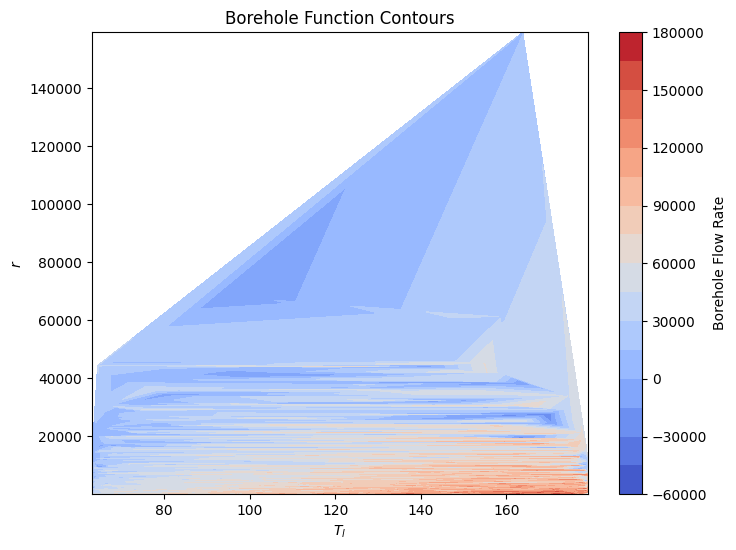

In [12]:
plot_2d_contours(bh_inputs, bh_output, xvar='T_l', yvar='r')

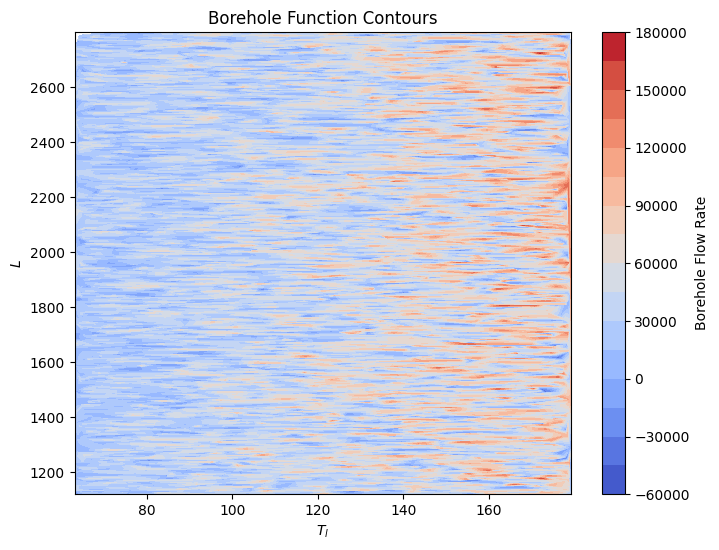

In [13]:
plot_2d_contours(bh_inputs, bh_output, xvar='T_l', yvar='L')

In [14]:
bh_output.min()

-53383.0446669191

In [15]:
np.log(40000/0.04)

13.815510557964274

Define problem, draw samples from low-discrepancy sequence, and perform sensitivity analysis

In [16]:
problem = {
    'num_vars': 8,
    'names': ['r_w', 'r', 'T_u', 'H_u', 'T_l', 'H_l', 'L', 'K_w'],
    'bounds': [[0.05, 0.15],
              [100, 50000],
              [63070, 115600],
              [990, 1110],
              [63.1, 116],
              [700, 820],
              [1120, 1680],
              [9855, 12045]]
}

If we ask for $N$ samples, the sampler will return $N * (2D + 2)$ samples, where $D$ is the number of model inputs.

In [17]:
param_values = saltelli.sample(problem, 2048)

/var/folders/0m/401pb5hj7y59vbxjhd49jjj80000gp/T/ipykernel_18146/2996815261.py:1: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5. Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 2048)


In [18]:
param_values.shape

(36864, 8)

In [19]:
Y = bh.evaluate2(param_values)
Y.shape

(36864,)

In [20]:
Si = sobol.analyze(problem, Y)

In [21]:
print(Si['S1'])

[ 9.11182883e-03  1.33943437e-01  3.88745258e-06  2.08452463e-01
  4.21206710e-01  2.08755024e-01  4.96443146e-08 -5.87974576e-08]


In [22]:
print(Si['ST'])

[1.03235999e-02 1.38088054e-01 5.81392272e-07 2.17229918e-01
 4.41084482e-01 2.16149030e-01 3.66512373e-11 7.26072450e-12]


In [23]:
print("x1-x2:", Si['S2'][0,1])
print("x1-x3:", Si['S2'][0,2])
print("x2-x3:", Si['S2'][1,2])

x1-x2: 0.0012373676208839723
x1-x3: 0.0004101997161895186
x2-x3: -0.006546579203180892


In [24]:
total_Si, first_Si, second_Si = Si.to_df()

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

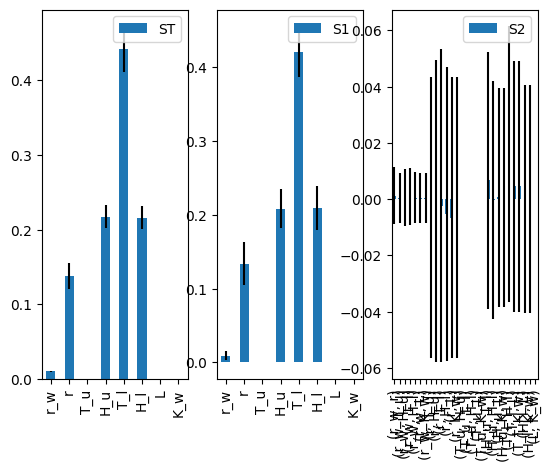

In [25]:
Si.plot()

In [39]:
first_Si

,S1,S1_conf
r_w,9.111829e-03,6.199896e-03
r,1.339434e-01,2.934738e-02
T_u,3.887453e-06,4.800716e-05
H_u,2.084525e-01,2.680347e-02
T_l,4.212067e-01,3.433224e-02
H_l,2.087550e-01,2.972677e-02
L,4.964431e-08,1.025524e-07
K_w,-5.879746e-08,1.277519e-07


In [37]:
from SALib.plotting.bar import plot as barplot

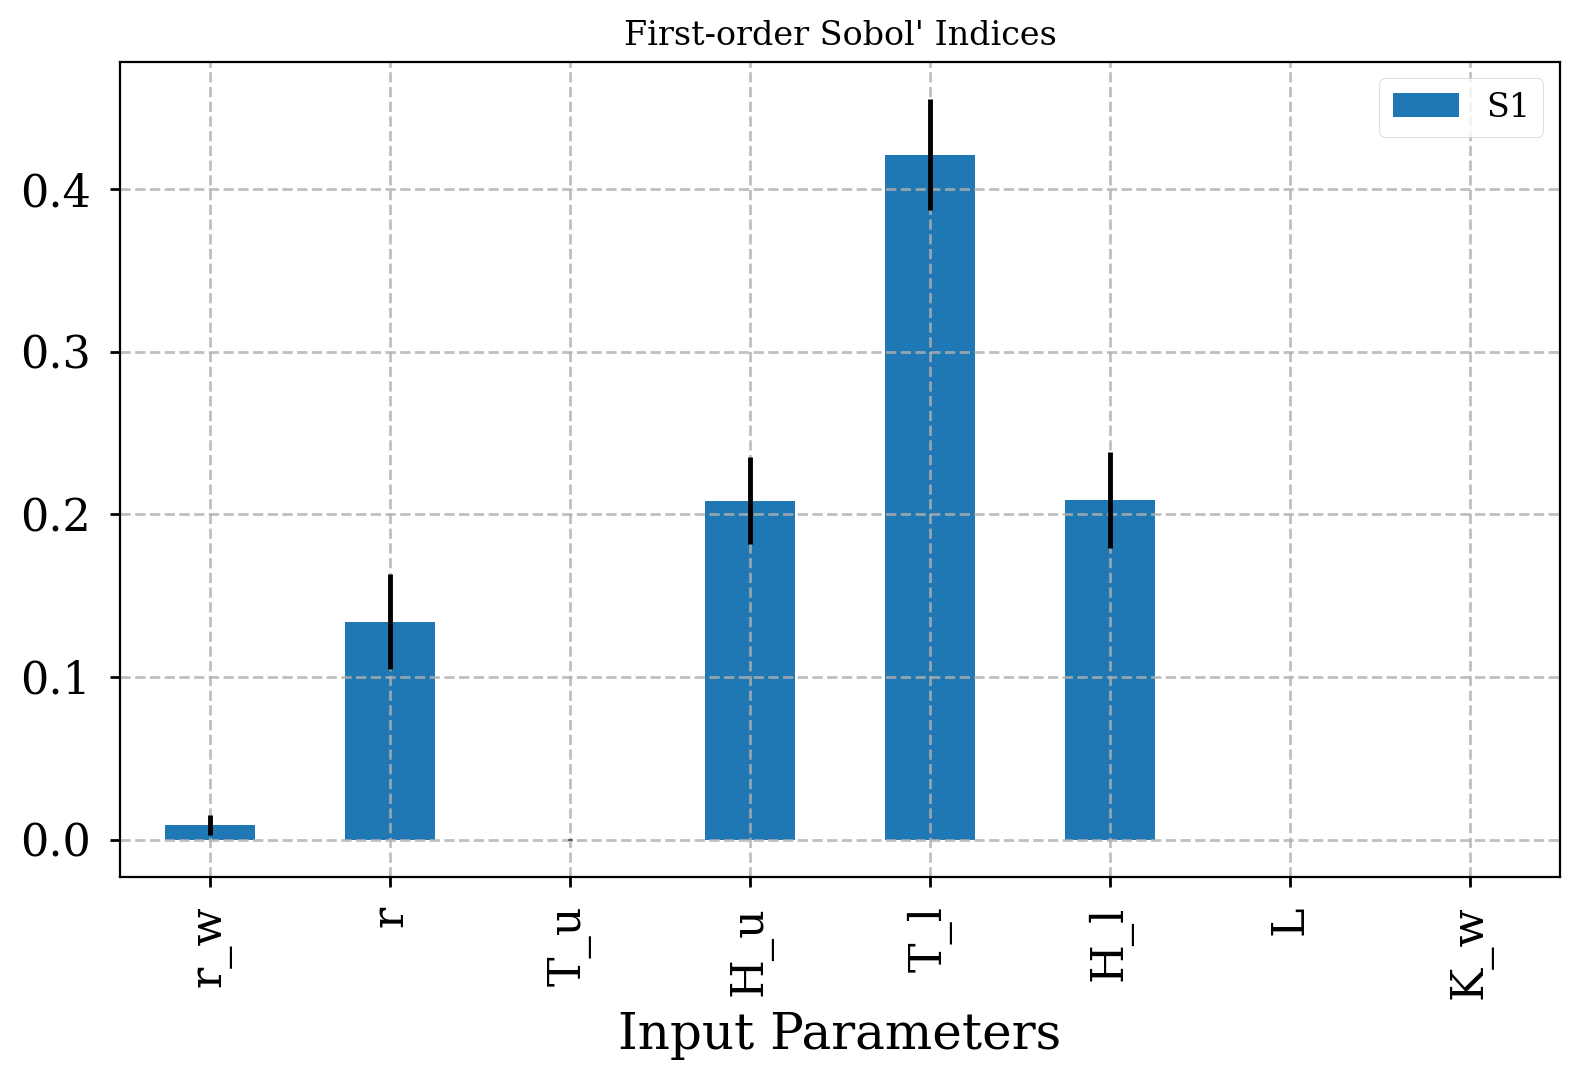

In [41]:
ax_si = barplot(first_Si)
ax_si.set_xlabel("Input Parameters")
ax_si.set_title("First-order Sobol' Indices")
plt.tight_layout()
plt.savefig("Borehole_main_mc.png", dpi=200)

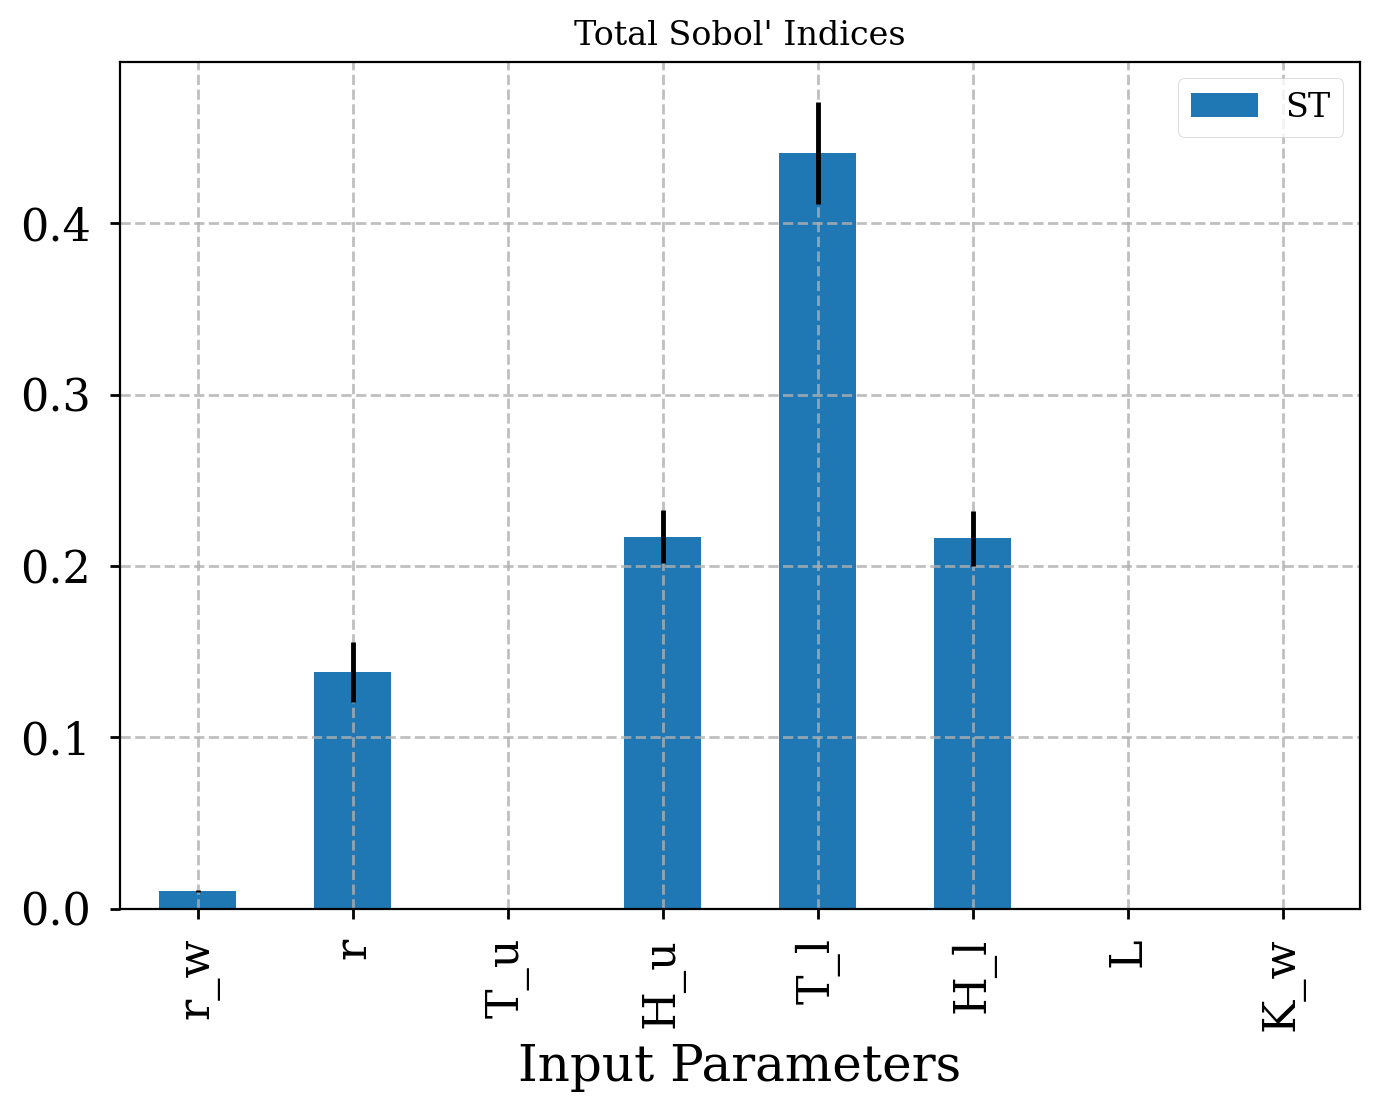

In [43]:
ax_st = barplot(total_Si)
ax_st.set_xlabel("Input Parameters")
ax_st.set_title("Total Sobol' Indices")
plt.savefig("Borehole_total_mc.png", dpi=200)